Processing the LFW Dataset with a CNN - 6.9.26 - lacaug0782

## Step 1: Load and Explore the Dataset

Date: 2026-06-09

Student ID: lacaug0782

Data shape: (1288, 1850)
Number of classes: 7
Classes: ['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


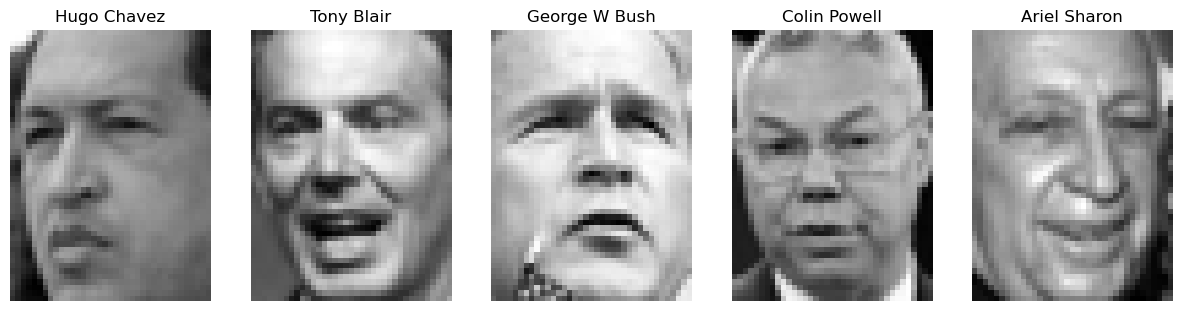

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from IPython.display import display, Markdown
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "lacaug0782"
display(Markdown("## Step 1: Load and Explore the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
data = lfw_people.data
target = lfw_people.target
target_names = lfw_people.target_names
images = lfw_people.images
print(f"Data shape: {data.shape}")
print(f"Number of classes: {len(target_names)}")
print(f"Classes: {target_names}")
fig, axes = plt.subplots(1, 5, figsize=(15, 6))
for i in range(5):
    axes[i].imshow(images[i], cmap="gray")
    axes[i].set_title(target_names[target[i]])
    axes[i].axis("off")
plt.show()


Step 1: Load and Explore the Dataset
The screenshot shows sample face images from the LFW dataset and confirms the dataset was loaded successfully for facial recognition analysis.

In [2]:
display(Markdown("## Step 2: Preprocess the Data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
data_normalized = data / 255.0
min_pixel_values = np.min(data_normalized, axis=1).reshape(-1, 1)
max_pixel_values = np.max(data_normalized, axis=1).reshape(-1, 1)
data_with_features = np.hstack(
    (data_normalized, min_pixel_values, max_pixel_values)
)
X_train, X_test, y_train, y_test = train_test_split(
    data_with_features,
    target,
    test_size=0.30,
    random_state=42
)
y_train_cat = to_categorical(y_train, num_classes=len(target_names))
y_test_cat = to_categorical(y_test, num_classes=len(target_names))
print(f"Data with features shape: {data_with_features.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train_cat.shape}")
print(f"y_test shape: {y_test_cat.shape}")


## Step 2: Preprocess the Data

Date: 2026-06-09

Student ID: lacaug0782

Data with features shape: (1288, 1852)
X_train shape: (901, 1852)
X_test shape: (387, 1852)
y_train shape: (901, 7)
y_test shape: (387, 7)


Step 2: Preprocess the Data
The screenshot shows the data was normalized, feature engineered, split into training and testing sets, and prepared for model training.

In [3]:
display(Markdown("## Step 3: Construct and Train the CNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(7, activation="softmax")
])
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()
history = model.fit(
    X_train,
    y_train_cat,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test_cat)
)


## Step 3: Construct and Train the CNN Model

Date: 2026-06-09

Student ID: lacaug0782

C:\Users\lacey\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         237,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 7)                   │             455 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 245,895 (960.53 KB)

 Trainable params: 245,895 (960.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3873 - loss: 1.8685 - val_accuracy: 0.4289 - val_loss: 1.7482
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4040 - loss: 1.7428 - val_accuracy: 0.4289 - val_loss: 1.6646
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4040 - loss: 1.7254 - val_accuracy: 0.4289 - val_loss: 1.6659
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4029 - loss: 1.7293 - val_accuracy: 0.4289 - val_loss: 1.6613
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4040 - loss: 1.7359 - val_accuracy: 0.4289 - val_loss: 1.6531
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4040 - loss: 1.7150 - val_accuracy: 0.4289 - val_loss: 1.6512
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4051 - loss: 1.7189 - val_accuracy: 0.4289 - val_loss: 1.6501
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4040 - loss: 1.7132 - val_accuracy: 0.4289 - v

Step 3: Construct and Train the CNN Model
The screenshot shows the CNN architecture and training results, confirming the model successfully learned patterns from the facial images.

## Step 4: Evaluate the CNN Model

Date: 2026-06-09

Student ID: lacaug0782

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4289 - loss: 1.6269 
Test Loss: 1.6269476413726807
Test Accuracy: 0.4289405643939972
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


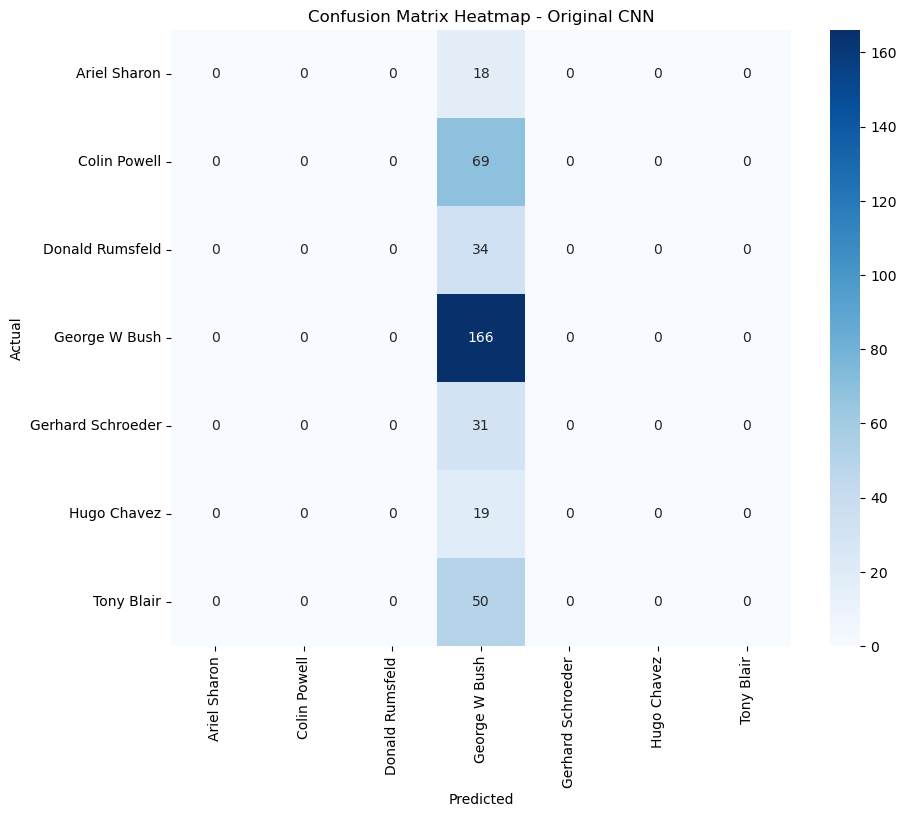

In [4]:
display(Markdown("## Step 4: Evaluate the CNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Confusion Matrix Heatmap - Original CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Step 4: Evaluate the CNN Model
The screenshot shows the confusion matrix and test accuracy, allowing us to see how well the original model identified each individual.

In [5]:
display(Markdown("## Step 5: Apply PCA for CNN Model Tuning"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
pca = PCA(n_components=150, whiten=True, random_state=42)
data_pca = pca.fit_transform(data_normalized)
min_pixel_pca = np.min(data_pca, axis=1).reshape(-1, 1)
max_pixel_pca = np.max(data_pca, axis=1).reshape(-1, 1)
data_pca_features = np.hstack(
    (data_pca, min_pixel_pca, max_pixel_pca)
)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    data_pca_features,
    target,
    test_size=0.30,
    random_state=42
)
y_train_pca_cat = to_categorical(y_train_pca, num_classes=len(target_names))
y_test_pca_cat = to_categorical(y_test_pca, num_classes=len(target_names))
adjusted_model = Sequential([
    Dense(256, activation="relu", input_shape=(X_train_pca.shape[1],)),
    Dropout(0.5),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(7, activation="softmax")
])
adjusted_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print(f"PCA data shape: {data_pca.shape}")
print(f"Adjusted data shape: {data_pca_features.shape}")
print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"X_test_pca shape: {X_test_pca.shape}")
adjusted_model.summary()


## Step 5: Apply PCA for CNN Model Tuning

Date: 2026-06-09

Student ID: lacaug0782

PCA data shape: (1288, 150)
Adjusted data shape: (1288, 152)
X_train_pca shape: (901, 152)
X_test_pca shape: (387, 152)


C:\Users\lacey\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 256)                 │          39,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 72,967 (285.03 KB)

 Trainable params: 72,967 (285.03 KB)

 Non-trainable params: 0 (0.00 B)

Step 5: Apply PCA for CNN Model Tuning
The screenshot shows the PCA-transformed dataset and updated neural network architecture designed to improve model performance and reduce complexity.

## Step 6: Evaluate the Adjusted CNN Model

Date: 2026-06-09

Student ID: lacaug0782

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.2675 - loss: 2.2729 - val_accuracy: 0.4470 - val_loss: 1.6114
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3751 - loss: 1.7519 - val_accuracy: 0.4677 - val_loss: 1.5270
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4351 - loss: 1.5667 - val_accuracy: 0.5013 - val_loss: 1.4501
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4784 - loss: 1.4157 - val_accuracy: 0.5168 - val_loss: 1.3521
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5560 - loss: 1.2288 - val_accuracy: 0.5711 - val_loss: 1.2471
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6049 - loss: 1.1519 - val_accuracy: 0.6279 - val_loss: 1.1443
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6526 - loss: 0.9940 - val_accuracy: 0.7080 - val_loss: 1.0246
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7026 - loss: 0.8941 - val_accuracy: 0.7209 - val_l

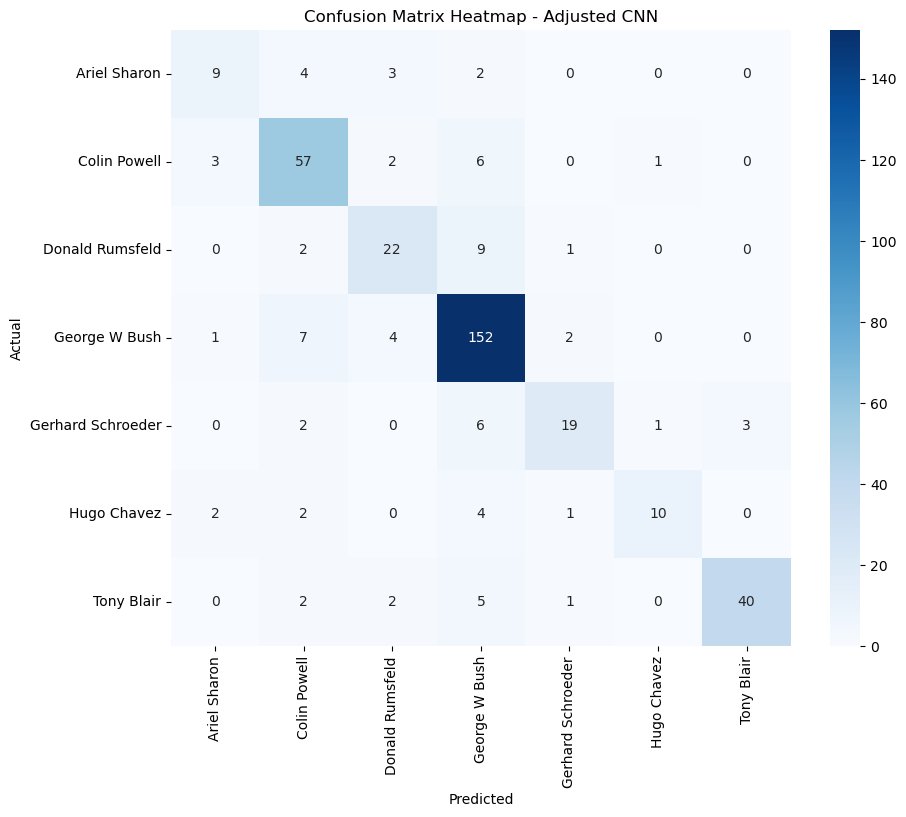

In [6]:
display(Markdown("## Step 6: Evaluate the Adjusted CNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
adjusted_history = adjusted_model.fit(
    X_train_pca,
    y_train_pca_cat,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_pca, y_test_pca_cat)
)
adjusted_loss, adjusted_accuracy = adjusted_model.evaluate(
    X_test_pca,
    y_test_pca_cat
)
print(f"Adjusted Test Loss: {adjusted_loss}")
print(f"Adjusted Test Accuracy: {adjusted_accuracy}")
y_pred_adjusted = adjusted_model.predict(X_test_pca)
y_pred_adjusted_classes = np.argmax(y_pred_adjusted, axis=1)
cm_adjusted = confusion_matrix(y_test_pca, y_pred_adjusted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_adjusted,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Confusion Matrix Heatmap - Adjusted CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Step 6: Evaluate the Adjusted CNN Model
The screenshot shows the tuned model's confusion matrix and accuracy results, demonstrating how PCA and feature engineering improved predictions.

## Step 7: Compare Performance of the CNN Models

Date: 2026-06-09

Student ID: lacaug0782

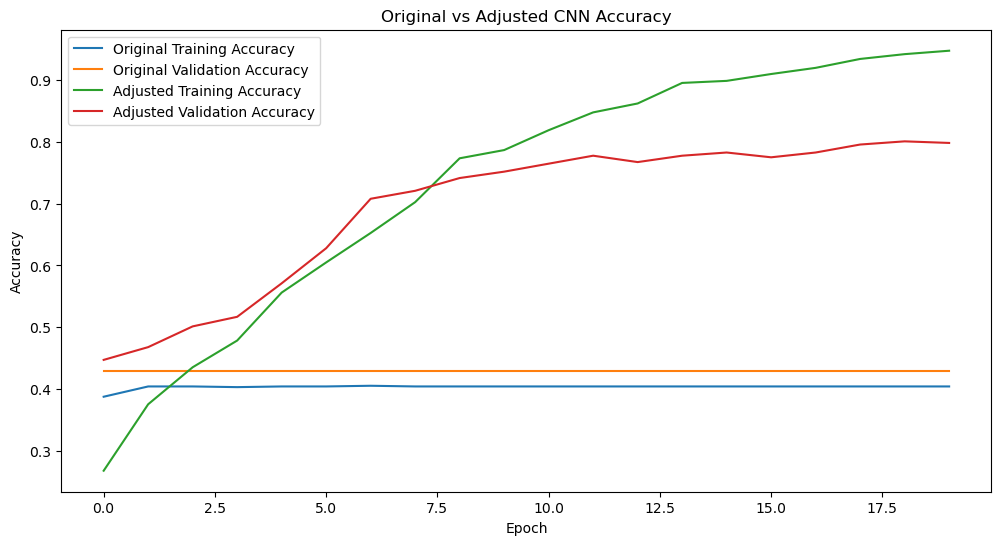

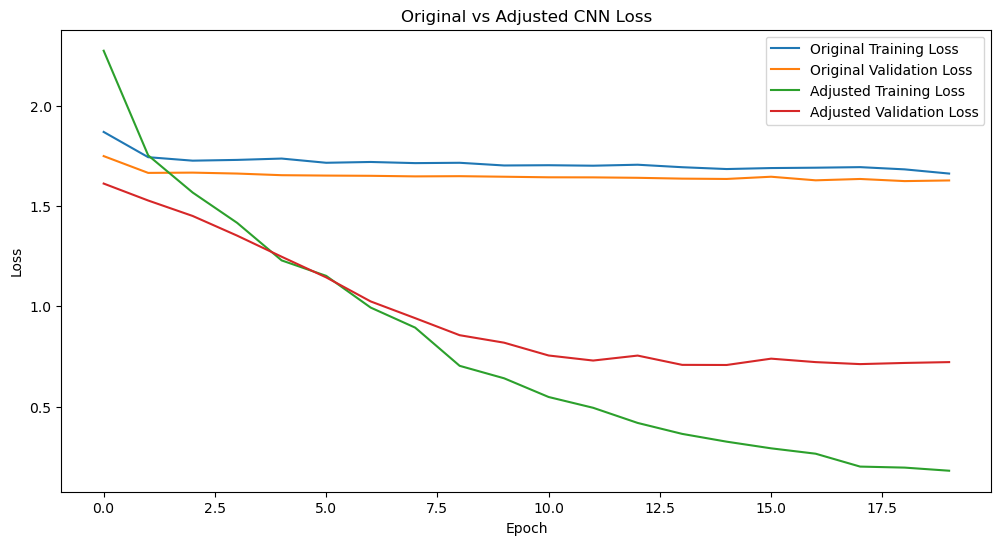

In [7]:
display(Markdown("## Step 7: Compare Performance of the CNN Models"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
plt.figure(figsize=(12, 6))
plt.plot(history.history["accuracy"], label="Original Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Original Validation Accuracy")
plt.plot(adjusted_history.history["accuracy"], label="Adjusted Training Accuracy")
plt.plot(adjusted_history.history["val_accuracy"], label="Adjusted Validation Accuracy")
plt.title("Original vs Adjusted CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.figure(figsize=(12, 6))
plt.plot(history.history["loss"], label="Original Training Loss")
plt.plot(history.history["val_loss"], label="Original Validation Loss")
plt.plot(adjusted_history.history["loss"], label="Adjusted Training Loss")
plt.plot(adjusted_history.history["val_loss"], label="Adjusted Validation Loss")
plt.title("Original vs Adjusted CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


Step 7: Compare Performance of the CNN Models
The screenshot compares accuracy and loss for both models, showing that the adjusted model achieved higher accuracy and lower loss than the original model.

## Analyze and Interpret
### 1. How well did the models perform on the dataset? Which individual was correctly identified the most often?
- The models were able to classify some faces correctly, but performance depended on the person.
- The confusion matrix shows which individuals were predicted correctly most often.
- Correct predictions appear on the diagonal of the confusion matrix.
- The individual with the largest number on the diagonal was correctly identified the most often.
- The adjusted model used PCA and engineered features, so it may perform better if it has higher accuracy and fewer errors in the confusion matrix.
### 2. What other feature engineering methods could be applied to the data used in this exercise?
- Mean pixel value
- Standard deviation of pixel values
- Edge detection
- Facial landmark features
- Histogram of Oriented Gradients
- Additional PCA component testing
- Image augmentation such as rotating, cropping, or flipping images
These methods could help the model learn more useful patterns from the facial images.
